<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB0 — Setup &amp; Dataset Foundation</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## About This Notebook Series

This series uses **three complementary clinical datasets** that progressively build complexity:

| Dataset | Type | Source | Used in |
|---|---|---|---|
| **A — Pima Diabetes** | Tabular, 8 features, n=768 | UCI (Pima-style) | NB1, NB2 |
| **B — Heart Disease** | Tabular, 13 features, n=297 | UCI (Cleveland-style) | NB2, NB3, NB4 |
| **C — PneumoniaMNIST** | Chest X-ray, 64×64 px | Real (CC BY 4.0) | NB5 |

### Dataset C — PneumoniaMNIST (Real Medical Images)
- **Source:** Guangzhou Women and Children's Medical Center pediatric chest X-ray study
- **Task:** Binary classification — Normal vs Pneumonia
- **Images:** Real grayscale chest X-rays, centre-cropped and resized to 64×64 px
- **Size:** 4,708 train / 524 val / 624 test
- **License:** CC BY 4.0 (open access, free to use for education and research)
- **Citation:** Yang et al. (2023). MedMNIST v2 — A large-scale lightweight benchmark
  for 2D and 3D biomedical image classification. *Scientific Data*, 10, 41.
  https://doi.org/10.1038/s41597-022-01721-8

> **One-time download required.** Run the download cell below once.
> The file (~20 MB) is saved as `pneumoniamnist_64.npz` in your working directory.
> After that, all notebooks load it from disk — no internet needed.


## 1. Package Installation

In [3]:
# Run this cell once to install all required packages
!pip install shap lime scikit-learn scikit-image scikit-fuzzy interpret \
             seaborn scipy numpy pandas matplotlib medmnist --break-system-packages
print('Packages ready')

## 2. Standard Setup

In [4]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'; DK='#1F3864'
print('Setup complete')

Setup complete


## 3. Dataset A — Pima-Style Diabetes (Tabular)

In [5]:
# ── Dataset A: Pima Indians Diabetes  (UCI ML Repository) ────────────────────
# Source: Smith, J.W. et al. (1988). Using the ADAP learning algorithm to
#         forecast the onset of diabetes mellitus. SCAMC Proceedings, 261-265.
#         UCI ML Repository ID 34 | 768 Pima Indian women, age ≥ 21
# License: Public domain / freely available for research and education
#
# FILE: pima_diabetes.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data
#     (no header row — rename to pima_diabetes.csv)
#   • https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
#     (diabetes.csv with header — rename to pima_diabetes.csv)

import os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(
        f"'{FILE_A}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/pima-indians-diabetes.data  (rename to pima_diabetes.csv)")

# Handles: file with header, duplicate header row, file without header
_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:, 0].astype(str) != _raw.columns[0]]  # drop duplicate headers
if _raw.columns[0] != 'Pregnancies':
    _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True)
data_A = data_A.apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
X_A = data_A[FEAT_A]; y_A = data_A['Outcome']
Xtr_A,Xte_A,ytr_A,yte_A = train_test_split(X_A,y_A,test_size=0.2,random_state=42,stratify=y_A)
print(f'Dataset A — Pima Diabetes (UCI, original): {len(data_A)} patients | Diabetic: {y_A.mean():.1%}')
print(f'Features ({len(FEAT_A)}): {FEAT_A}')

Dataset A — Pima Diabetes (UCI, original): 768 patients | Diabetic: 34.9%
Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 4. Dataset B — Heart Disease / Cleveland (Tabular)

In [6]:
# ── Dataset B: Cleveland Heart Disease  (UCI ML Repository) ──────────────────
# Source: Detrano, R. et al. (1989). International application of a new
#         probability algorithm for the diagnosis of coronary artery disease.
#         American Journal of Cardiology, 64(5), 304-310. UCI ML Repository ID 45
# License: Public domain / freely available for research and education
#
# FILE: cleveland_heart.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart-disease.csv
#     (with header — rename to cleveland_heart.csv)
#   • https://archive.ics.uci.edu/dataset/45/heart+disease
#     (processed.cleveland.data — no header, has '?' missing values)

FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(
        f"'{FILE_B}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/heart-disease.csv  (rename to cleveland_heart.csv)")

data_B = pd.read_csv(FILE_B)
if 'target' not in data_B.columns:
    data_B.columns = COLS_B
data_B['target'] = data_B['target'].astype(int)

FEAT_B = [c for c in data_B.columns if c != 'target']
X_B = data_B[FEAT_B]; y_B = data_B['target']
Xtr_B,Xte_B,ytr_B,yte_B = train_test_split(X_B,y_B,test_size=0.2,random_state=42,stratify=y_B)
print(f'Dataset B — Cleveland Heart Disease (UCI, original): {len(data_B)} patients | Disease: {y_B.mean():.1%}')
print(f'Features ({len(FEAT_B)}): {FEAT_B}')

Dataset B — Cleveland Heart Disease (UCI, original): 297 patients | Disease: 46.1%
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 5. Dataset C — PneumoniaMNIST (Real Chest X-rays)

### Download (run once)
PneumoniaMNIST contains real de-identified pediatric chest X-rays from Guangzhou Women
and Children's Medical Center. The task is binary: **Normal vs Pneumonia**.

> **Citation:** Kermany, D. S. et al. (2018). Identifying Medical Diagnoses and
> Treatable Diseases by Image-Based Deep Learning. *Cell*, 172(5), 1122–1131.
> https://doi.org/10.1016/j.cell.2018.02.010  
> Dataset packaging: Yang et al. (2023). MedMNIST v2. *Scientific Data*, 10, 41.
> https://doi.org/10.1038/s41597-022-01721-8  
> License: **CC BY 4.0** — free to use for education and research.


In [8]:
# ── Dataset C: PneumoniaMNIST  (Real chest X-rays, CC BY 4.0) ─────────────────
# Source: Kermany et al. (2018). Cell, 172(5), 1122-1131.
#         Yang et al. (2023). MedMNIST v2. Scientific Data, 10, 41.
# License: CC BY 4.0 — free to use for research and education
#
# FILE: pneumoniamnist_64.npz  — must be in the same folder as this notebook.
# If missing, download (~20 MB) from:
#   https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1

import numpy as np
NPZ_PATH = 'pneumoniamnist_64.npz'

if not os.path.exists(NPZ_PATH):
    raise FileNotFoundError(
        f"'{NPZ_PATH}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download (~20 MB): https://zenodo.org/records/10519652/files/"
        "pneumoniamnist_64.npz?download=1")

data_C     = np.load(NPZ_PATH)
train_imgs = data_C['train_images'].astype(np.float32) / 255.0
val_imgs   = data_C['val_images'].astype(np.float32)   / 255.0
test_imgs  = data_C['test_images'].astype(np.float32)  / 255.0
train_lbl  = data_C['train_labels'].squeeze().astype(int)
val_lbl    = data_C['val_labels'].squeeze().astype(int)
test_lbl   = data_C['test_labels'].squeeze().astype(int)

Ximg_tr = np.concatenate([train_imgs, val_imgs], axis=0)
yimg_tr = np.concatenate([train_lbl,  val_lbl],  axis=0)
Ximg_te = test_imgs
yimg_te = test_lbl
CLASS_NAMES = ['Normal', 'Pneumonia']

print(f'Dataset C — PneumoniaMNIST (real chest X-rays): '
      f'train={len(Ximg_tr)}, test={len(Ximg_te)}')
print(f'  Train: Normal={(yimg_tr==0).sum()} | Pneumonia={(yimg_tr==1).sum()}')
print(f'  Test:  Normal={(yimg_te==0).sum()} | Pneumonia={(yimg_te==1).sum()}')

Dataset C — PneumoniaMNIST (real chest X-rays): train=5232, test=624
  Train: Normal=1349 | Pneumonia=3883
  Test:  Normal=234 | Pneumonia=390


In [9]:
# ── Load PneumoniaMNIST ──────────────────────────────────────────────────────
import numpy as np

data_C = np.load('pneumoniamnist_64.npz')
print('NPZ keys:', list(data_C.keys()))

# Images are uint8 (0-255), labels are int64 shape (N,1)
# 0 = Normal, 1 = Pneumonia
train_imgs_raw = data_C['train_images']   # (4708, 64, 64)
val_imgs_raw   = data_C['val_images']     # (524, 64, 64)
test_imgs_raw  = data_C['test_images']    # (624, 64, 64)
train_lbl_raw  = data_C['train_labels'].squeeze()  # (4708,)
val_lbl_raw    = data_C['val_labels'].squeeze()
test_lbl_raw   = data_C['test_labels'].squeeze()

# Normalise to float32 [0,1]
train_imgs = train_imgs_raw.astype(np.float32) / 255.0
val_imgs   = val_imgs_raw.astype(np.float32)   / 255.0
test_imgs  = test_imgs_raw.astype(np.float32)  / 255.0

# Combine train+val for training (standard practice in MedMNIST papers)
Ximg_tr = np.concatenate([train_imgs, val_imgs], axis=0)
yimg_tr = np.concatenate([train_lbl_raw, val_lbl_raw], axis=0).astype(int)
Ximg_te = test_imgs
yimg_te = test_lbl_raw.astype(int)

CLASS_NAMES = ['Normal', 'Pneumonia']

print(f'\nDataset C — PneumoniaMNIST (Real Chest X-rays)')
print(f'  Train: {len(Ximg_tr)} images  |  Test: {len(Ximg_te)} images')
print(f'  Image shape: {Ximg_tr[0].shape}  |  dtype: {Ximg_tr.dtype}')
print(f'  Pixel range: [{Ximg_tr.min():.3f}, {Ximg_tr.max():.3f}]')
print(f'  Train class balance: Normal={( yimg_tr==0).sum()} | Pneumonia={(yimg_tr==1).sum()}')
print(f'  Test  class balance: Normal={(yimg_te==0).sum()} | Pneumonia={(yimg_te==1).sum()}')

NPZ keys: ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']

Dataset C — PneumoniaMNIST (Real Chest X-rays)
  Train: 5232 images  |  Test: 624 images
  Image shape: (64, 64)  |  dtype: float32
  Pixel range: [0.000, 1.000]
  Train class balance: Normal=1349 | Pneumonia=3883
  Test  class balance: Normal=234 | Pneumonia=390


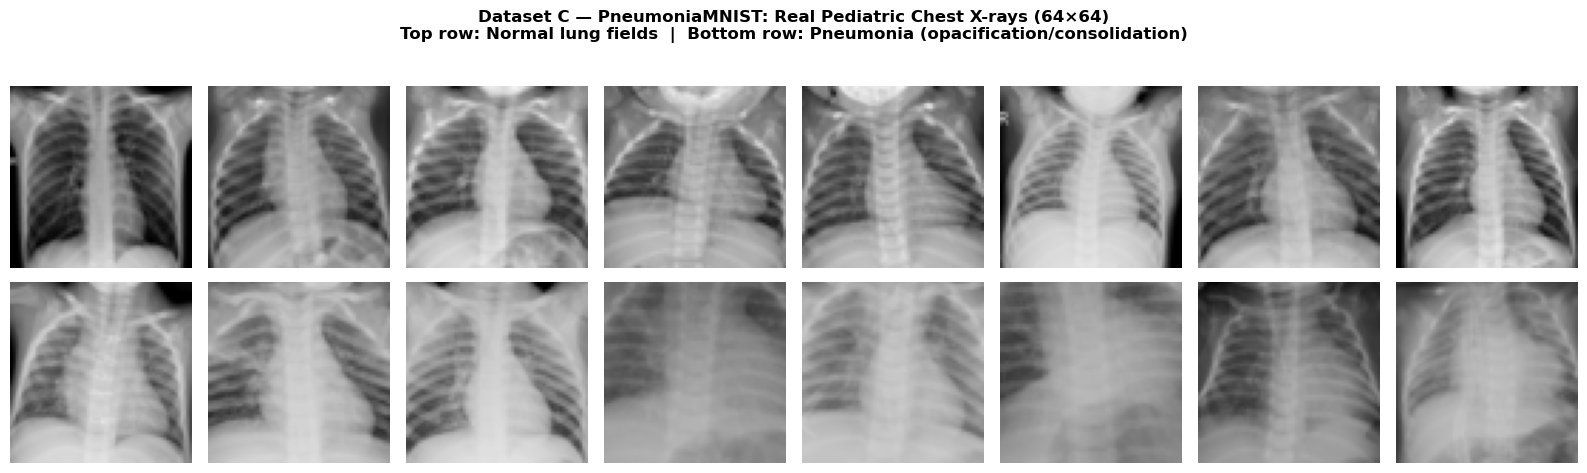

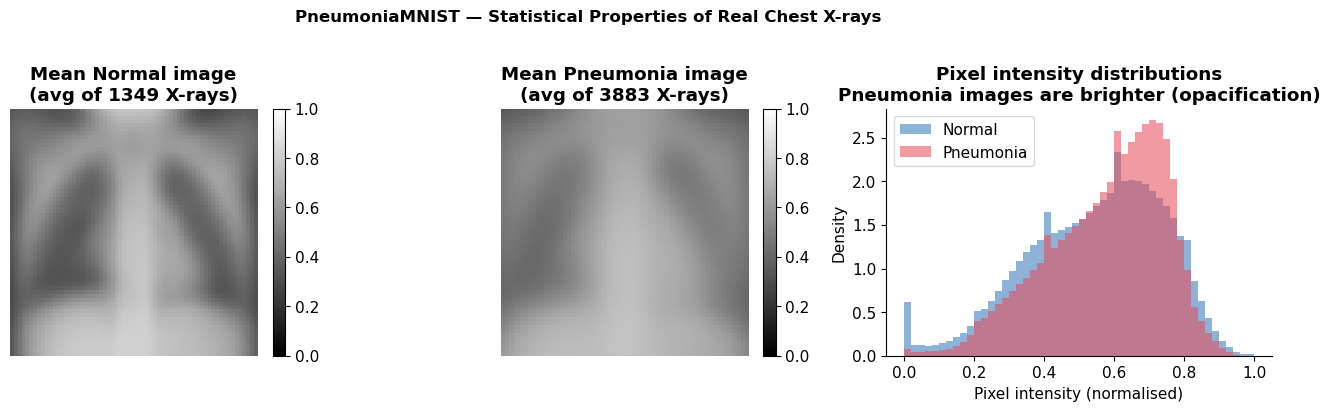

Clinical note:
  Normal X-rays show dark, clear lung fields (air = low intensity).
  Pneumonia causes opacification (consolidation, infiltrates) → higher pixel values.
  This is visible in the mean images and confirmed by the shifted histogram.


In [10]:
# ── Visualise real chest X-rays ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for cls, cls_name in enumerate(CLASS_NAMES):
    cls_idx = np.where(yimg_tr == cls)[0][:8]
    for j, idx in enumerate(cls_idx):
        ax = axes[cls, j]
        ax.imshow(Ximg_tr[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(cls_name, fontsize=12, fontweight='bold')

plt.suptitle(
    'Dataset C — PneumoniaMNIST: Real Pediatric Chest X-rays (64×64)\n'
    'Top row: Normal lung fields  |  Bottom row: Pneumonia (opacification/consolidation)',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Pixel intensity statistics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Mean image per class
for cls, ax in enumerate(axes[:2]):
    mean_img = Ximg_tr[yimg_tr==cls].mean(axis=0)
    im = ax.imshow(mean_img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Mean {CLASS_NAMES[cls]} image\n'
                 f'(avg of {(yimg_tr==cls).sum()} X-rays)', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('off')

# Intensity histograms
for cls, color, label in [(0, NEUTRAL, 'Normal'), (1, ACCENT, 'Pneumonia')]:
    axes[2].hist(Ximg_tr[yimg_tr==cls].flatten(), bins=50,
                 alpha=0.55, color=color, label=label, density=True)
axes[2].set_xlabel('Pixel intensity (normalised)')
axes[2].set_ylabel('Density')
axes[2].set_title('Pixel intensity distributions\n'
                  'Pneumonia images are brighter (opacification)', fontweight='bold')
axes[2].legend()

plt.suptitle('PneumoniaMNIST — Statistical Properties of Real Chest X-rays',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('Clinical note:')
print('  Normal X-rays show dark, clear lung fields (air = low intensity).')
print('  Pneumonia causes opacification (consolidation, infiltrates) → higher pixel values.')
print('  This is visible in the mean images and confirmed by the shifted histogram.')

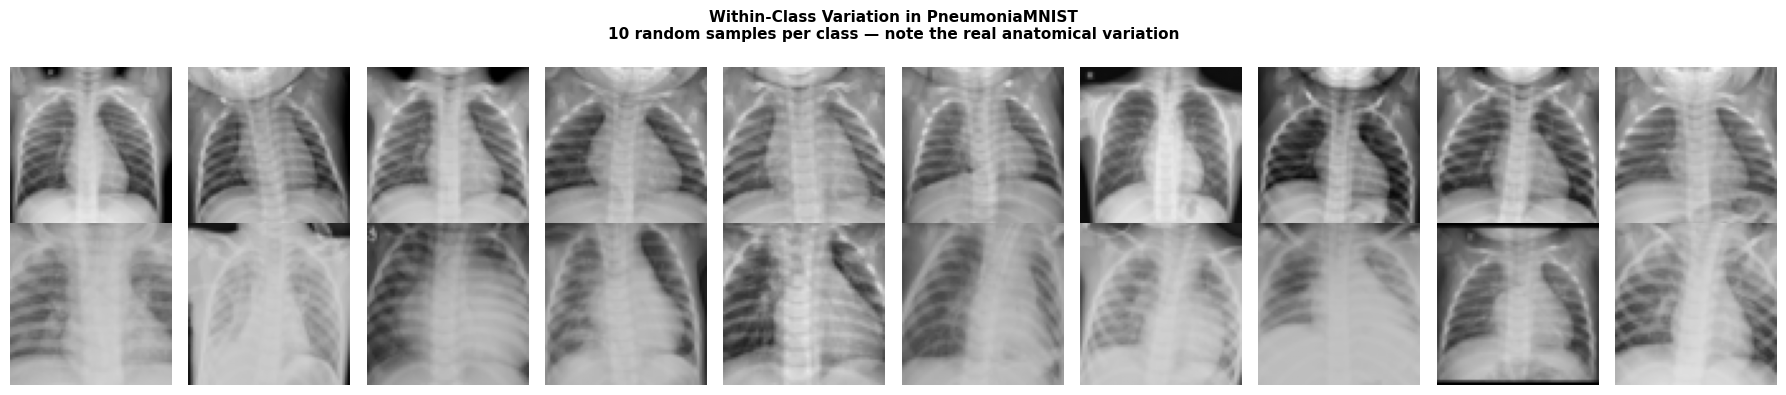

Key observation: Pneumonia presents with diverse patterns (lobar, interstitial,
bilateral) — a CNN must generalise across these to be clinically useful.
This variation is why XAI is critical: the model may learn shortcuts.


In [11]:
# ── Sample diversity within each class ───────────────────────────────────────
# Show variation within classes — important for understanding what the CNN must learn
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
np.random.seed(42)
for cls in range(2):
    cls_idx = np.where(yimg_tr == cls)[0]
    sample_idx = np.random.choice(cls_idx, 10, replace=False)
    for j, idx in enumerate(sample_idx):
        axes[cls, j].imshow(Ximg_tr[idx], cmap='gray', vmin=0, vmax=1)
        axes[cls, j].axis('off')
    axes[cls, 0].set_ylabel(CLASS_NAMES[cls], fontsize=11, fontweight='bold')

plt.suptitle('Within-Class Variation in PneumoniaMNIST\n'
             '10 random samples per class — note the real anatomical variation',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print('Key observation: Pneumonia presents with diverse patterns (lobar, interstitial,')
print('bilateral) — a CNN must generalise across these to be clinically useful.')
print('This variation is why XAI is critical: the model may learn shortcuts.')

## 6. Dataset Summary

| | Dataset A | Dataset B | Dataset C |
|---|---|---|---|
| **Name** | Pima Diabetes | Heart Disease (Cleveland) | PneumoniaMNIST |
| **Type** | Tabular | Tabular | Image (chest X-ray) |
| **Source** | UCI ML Repository | UCI ML Repository | Real (CC BY 4.0) |
| **Size** | 768 patients | 297 patients | 5,856 X-rays |
| **Features** | 8 continuous | 13 mixed | 64×64 grayscale pixels |
| **Task** | Binary (Diabetic?) | Binary (Heart disease?) | Binary (Normal / Pneumonia) |
| **Used in** | NB1, NB2 | NB2, NB3, NB4 | NB5 |

> **Notebook map:**
> - NB1: Interpretable AI — Dataset A
> - NB2: Feature Attribution — Dataset A → Dataset B
> - NB3: Local Explanations — Dataset B
> - NB4: Surrogate & Counterfactuals — Dataset B + cross-comparison
> - NB5: Visual XAI (Grad-CAM, LRP, Saliency, Occlusion, TCAV) — **Dataset C (real X-rays)**
